# Week 3: Sentiment Analysis and Named Entity Recognition
**Two mini-projects in one framework**
- **Project A, Sentiment analysis:** IMDB movie reviews, comparing a lexicon method (VADER), a machine-learning model (TF-IDF + Linear SVM) and a pre-trained transformer (DistilBERT).
- **Project B, Named entity recognition (NER):** evaluated on the gold-annotated **CoNLL-2003** benchmark, comparing a rule-based tagger, a statistical model (spaCy) and a deep-learning model (BERT). The best systems are then applied to the IMDB reviews.
- **Integration:** NER finds *who* is mentioned and sentiment says *how* the review feels, giving entity-level sentiment.

**How to use this notebook**
- Run cells top to bottom with **Shift+Enter**, one at a time, and read each output.
- Each phase ends with a **"Note for your report"** box.
- For speed, switch Colab to a GPU first: **Runtime → Change runtime type → T4 GPU**. It also works on CPU, only slower (roughly 30 to 40 minutes in total).
- Figures and tables are saved to `outputs/` and zipped at the end. Random seeds are fixed (`SEED = 42`).

## Phase 0: Setup

In [1]:
!pip install -q vaderSentiment datasets
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os, re, sys, time, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
import torch
from spacy.tokens import Doc
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
os.makedirs("outputs", exist_ok=True)
SEED = 42
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

def save(name):
    plt.tight_layout()
    plt.savefig(f"outputs/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def metrics(y_true, pred):
    return {"Accuracy": accuracy_score(y_true, pred), "Precision": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred), "F1": f1_score(y_true, pred)}

# ---------- entity-level NER scoring (same rules as the CoNLL "conlleval" script) ----------
def get_entities(tags):
    """BIO tags -> list of (type, start, end) with end inclusive."""
    ents, start, typ = [], None, None
    for i, tag in enumerate(list(tags) + ["O"]):
        if tag == "O" or tag.startswith("B-") or (tag.startswith("I-") and tag[2:] != typ):
            if start is not None:
                ents.append((typ, start, i - 1))
                start, typ = None, None
            if tag != "O":
                start, typ = i, tag[2:]
    return ents

def _entity_sets(tag_lists):
    return {(i, t, s, e) for i, tags in enumerate(tag_lists) for (t, s, e) in get_entities(tags)}

def _prf(g, p):
    tp = len(g & p)
    pr, rc = (tp / len(p) if p else 0.0), (tp / len(g) if g else 0.0)
    return pr, rc, (2 * pr * rc / (pr + rc) if pr + rc else 0.0)

def entity_scores(gold, pred, types=("PER", "ORG", "LOC", "MISC")):
    """Strict entity-level scores: an entity is correct only if its boundaries AND type match exactly."""
    G, P = _entity_sets(gold), _entity_sets(pred)
    out = {"overall": _prf(G, P)}
    for t in types:
        g, p = {x for x in G if x[1] == t}, {x for x in P if x[1] == t}
        out[t] = _prf(g, p) + (len(g),)
    return out

def seq_p(gold, pred):  return entity_scores(gold, pred)["overall"][0]
def seq_r(gold, pred):  return entity_scores(gold, pred)["overall"][1]
def seq_f1(gold, pred): return entity_scores(gold, pred)["overall"][2]

def seq_report(gold, pred, output_dict=True):
    sc = entity_scores(gold, pred)
    return {t: {"precision": v[0], "recall": v[1], "f1-score": v[2], "support": v[3]} for t, v in sc.items() if t != "overall"}

Running on: cuda


## Phase 1: Datasets
**Why two datasets?** No popular public dataset has gold labels for *both* sentiment and named entities. Following the task, IMDB reviews are the common text for the framework (they carry gold sentiment labels and are full of named entities such as actors, directors and studios). Because IMDB has **no entity annotations**, the NER modules are *measured* on **CoNLL-2003** (news text with gold entity tags) and then applied to IMDB.

In [3]:
# ---------- IMDB (sentiment) ----------
ds = load_dataset("stanfordnlp/imdb")
train_df = ds["train"].to_pandas().drop_duplicates(subset="text").reset_index(drop=True)
test_df = ds["test"].to_pandas().drop_duplicates(subset="text").reset_index(drop=True)
overlap = set(train_df["text"]) & set(test_df["text"])
test_df = test_df[~test_df["text"].isin(overlap)].reset_index(drop=True)
print("IMDB -> train:", len(train_df), "| test:", len(test_df), "| overlap removed:", len(overlap))
print("Test class counts:", test_df["label"].value_counts().sort_index().to_dict())

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB -> train: 24904 | test: 24678 | overlap removed: 123
Test class counts: {0: 12266, 1: 12412}


In [4]:
# ---------- CoNLL-2003 (NER) ----------
def load_conll():
    for name, kw in [("lhoestq/conll2003", {}), ("eriktks/conll2003", {}),
                     ("eriktks/conll2003", {"revision": "refs/convert/parquet"})]:
        try:
            return load_dataset(name, **kw), name
        except Exception as e:
            print("Could not load", name, "->", str(e)[:120])
    raise RuntimeError("Could not load CoNLL-2003. Try: !pip install -q 'datasets<4'")

conll, conll_name = load_conll()

# Some copies store the tags as plain integers (no label names attached), others as ClassLabel or text.
# The tag order below is the standard CoNLL-2003 order used by the Hugging Face dataset.
STANDARD_NER_NAMES = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
tag_feature = conll["train"].features["ner_tags"]
tag_feature = getattr(tag_feature, "feature", tag_feature)
NER_NAMES = list(getattr(tag_feature, "names", None) or STANDARD_NER_NAMES)
print("Loaded:", conll_name, "| labels:", NER_NAMES)

def to_tags(split):
    return [[NER_NAMES[t] if isinstance(t, (int, np.integer)) else str(t) for t in ex] for ex in conll[split]["ner_tags"]]

train_tokens, train_tags = conll["train"]["tokens"], to_tags("train")
test_tokens, test_tags = conll["test"]["tokens"], to_tags("test")
print("CoNLL sentences -> train:", len(train_tokens), "| test:", len(test_tokens))

print("\nExample sentence:")
ex = 5
print(list(zip(test_tokens[ex], test_tags[ex])))

dataset_infos.json:   0%|          | 0.00/3.67k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.07MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  281kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Loaded: lhoestq/conll2003 | labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
CoNLL sentences -> train: 14041 | test: 3453

Example sentence:
[('China', 'B-LOC'), ('controlled', 'O'), ('most', 'O'), ('of', 'O'), ('the', 'O'), ('match', 'O'), ('and', 'O'), ('saw', 'O'), ('several', 'O'), ('chances', 'O'), ('missed', 'O'), ('until', 'O'), ('the', 'O'), ('78th', 'O'), ('minute', 'O'), ('when', 'O'), ('Uzbek', 'B-MISC'), ('striker', 'O'), ('Igor', 'B-PER'), ('Shkvyrin', 'I-PER'), ('took', 'O'), ('advantage', 'O'), ('of', 'O'), ('a', 'O'), ('misdirected', 'O'), ('defensive', 'O'), ('header', 'O'), ('to', 'O'), ('lob', 'O'), ('the', 'O'), ('ball', 'O'), ('over', 'O'), ('the', 'O'), ('advancing', 'O'), ('Chinese', 'B-MISC'), ('keeper', 'O'), ('and', 'O'), ('into', 'O'), ('an', 'O'), ('empty', 'O'), ('net', 'O'), ('.', 'O')]


,Train,Test
PER,6600,1617
ORG,6321,1661
LOC,7140,1668
MISC,3438,702
Total,23499,5648


Test entity counts match the published statistics: True


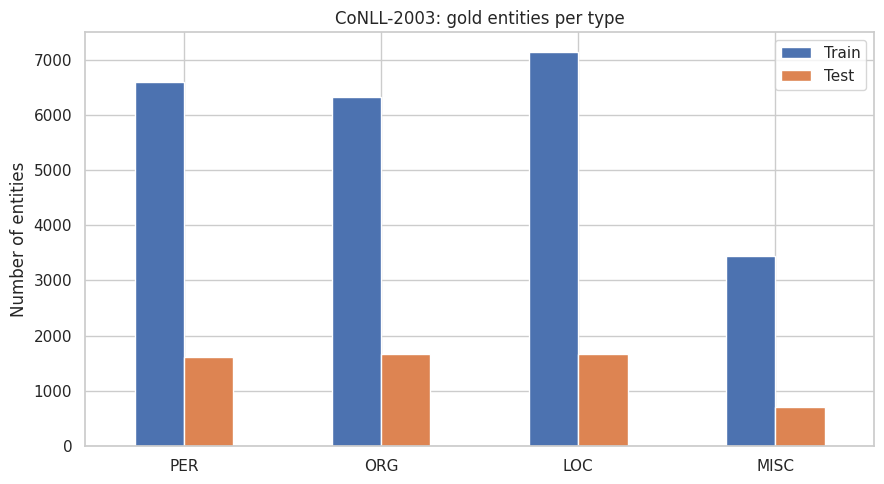

In [5]:
# Entity counts per type (gold)
def count_entities(tag_lists):
    c = collections.Counter(t for tags in tag_lists for (t, s, e) in get_entities(tags))
    return c

ent_counts = pd.DataFrame({"Train": count_entities(train_tags), "Test": count_entities(test_tags)}).reindex(["PER", "ORG", "LOC", "MISC"]).fillna(0).astype(int)
ent_counts.loc["Total"] = ent_counts.sum()
display(ent_counts)
ent_counts.to_csv("outputs/table_conll_entity_counts.csv")

# Sanity check: the published CoNLL-2003 English test set has 1,617 PER, 1,661 ORG, 1,668 LOC and 702 MISC entities
expected_test = {"PER": 1617, "ORG": 1661, "LOC": 1668, "MISC": 702}
actual_test = {k: int(ent_counts.loc[k, "Test"]) for k in expected_test}
print("Test entity counts match the published statistics:", actual_test == expected_test)
if actual_test != expected_test:
    print("WARNING: counts differ from the published ones", actual_test, "- the tag order may be different in this copy of the dataset.")

ent_counts.drop(index="Total").plot(kind="bar", color=["#4c72b0", "#dd8452"], rot=0)
plt.ylabel("Number of entities"); plt.title("CoNLL-2003: gold entities per type")
save("01_conll_entity_distribution")

> **Note for your report (Datasets):** IMDB sizes (train and test after cleaning), CoNLL sentence counts, the entity counts table, the four entity types (PER, ORG, LOC, MISC) and why two datasets are needed (no single public dataset has gold sentiment *and* entity labels). Mention that the NER systems are applied to IMDB afterwards.

## Phase 2: Preprocessing (different for each task)
- **Sentiment:** cleaning helps (HTML removal, lowercase, contractions, stopword removal keeping negations, lemmatization). This is the Week 2 "full" pipeline, which gave the best validation accuracy.
- **NER:** **capitalisation and punctuation are the main clues** to names, so the text is *not* lowercased or stripped. Only HTML is removed from the reviews, and CoNLL is already tokenised.

In [6]:
lemmatizer = WordNetLemmatizer()
NEGATIONS = {"no", "nor", "not", "never", "neither", "none", "nothing", "nowhere", "hardly", "barely"}
STOP = set(stopwords.words("english")) - NEGATIONS
CONTRACTIONS = [
    (r"won't", "will not"), (r"can't", "can not"), (r"cannot", "can not"), (r"shan't", "shall not"),
    (r"n't", " not"), (r"'re", " are"), (r"'ve", " have"), (r"'ll", " will"),
    (r"'d", " would"), (r"'m", " am"), (r"'s", ""),
]

def strip_html(t):
    return re.sub(r"<[^>]+>", " ", t)

def strip_urls(t):
    return re.sub(r"http\S+|www\.\S+", " ", t)

def expand_contractions(t):
    t = t.replace("\u2019", "'")
    for pat, rep in CONTRACTIONS:
        t = re.sub(pat, rep, t)
    return t

def keep_alpha(t):
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def remove_stop(t):
    return " ".join(w for w in t.split() if w not in STOP and len(w) > 1)

def lemmatize(t):
    return " ".join(lemmatizer.lemmatize(w) for w in t.split())

def full_clean(t):
    t = expand_contractions(strip_urls(strip_html(t)).lower())
    return lemmatize(remove_stop(keep_alpha(t)))

# takes 2-3 minutes
train_df["full"] = train_df["text"].map(full_clean)
test_df["full"] = test_df["text"].map(full_clean)

i = 3
print("RAW (HTML removed, case kept for NER):\n", strip_html(test_df.loc[i, "text"])[:300], "\n")
print("CLEANED (for the sentiment classifier):\n", test_df.loc[i, "full"][:300])

RAW (HTML removed, case kept for NER):
 STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning   Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigned to Columbus, a small but violent town in Mexico to help the police there with their efforts to stop a major  

CLEANED (for the sentiment classifier):
 star rating saturday night friday night friday morning sunday night monday morning former new orleans homicide cop jack robideaux jean claude van damme assigned columbus small violent town mexico help police effort stop major heroin smuggling operation town culprit turn ex military lead former comma


> **Note for your report (Preprocessing):** show the before/after example, and explain **why the two tasks need different preprocessing**: the sentiment classifier benefits from normalisation (smaller vocabulary, negations kept), but NER depends on capitalisation, punctuation and word order, so lowercasing would destroy the signal (this is tested in Phase 4).

## Phase 3: Project A, Sentiment analysis
Three approaches are compared:
1. **Lexicon-based:** VADER. We study the *scoring rule* (the decision threshold and whole-review vs sentence-averaged scores).
2. **Machine learning:** TF-IDF (unigrams + bigrams) + Linear SVM, trained on the IMDB training set (the best Week 2 model).
3. **Pre-trained transformer:** DistilBERT fine-tuned on SST-2, used as is (no training on IMDB).

### 3.1 Lexicon-based scoring with VADER
VADER returns a **compound score** between -1 and +1. We tune the threshold on a **training subsample** (never on the test set) and compare scoring the whole review with averaging the scores of its sentences.

Whole-review scoring: default threshold 0 -> 0.6940 | best threshold 0.5 -> 0.7052
Sentence-average scoring: default threshold 0 -> 0.7098 | best threshold 0.12 -> 0.7418


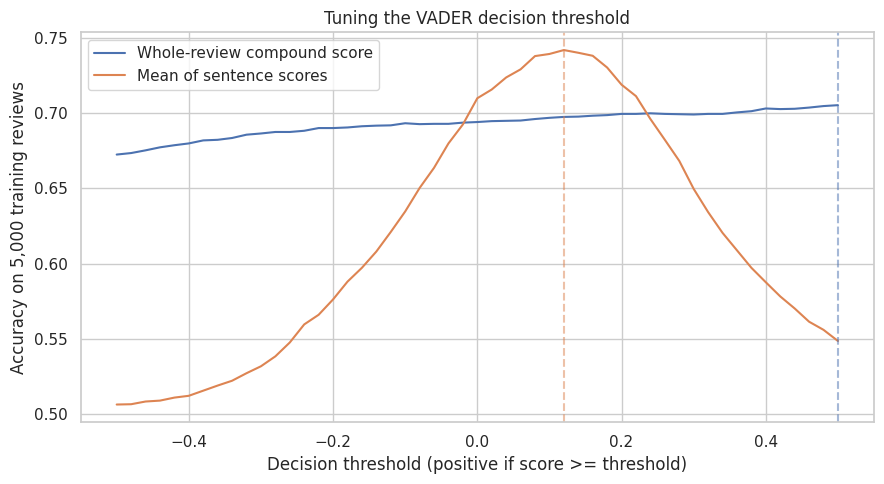

In [7]:
sia = SentimentIntensityAnalyzer()

def vader_whole(t):
    return sia.polarity_scores(strip_html(t))["compound"]

def vader_sent(t):
    sents = nltk.sent_tokenize(strip_html(t))
    return float(np.mean([sia.polarity_scores(s)["compound"] for s in sents])) if sents else 0.0

train_sub = train_df.groupby("label").sample(n=2500, random_state=SEED)      # 5,000 reviews for tuning
train_sub["v_whole"] = train_sub["text"].map(vader_whole)
train_sub["v_sent"] = train_sub["text"].map(vader_sent)

thresholds = np.round(np.arange(-0.5, 0.51, 0.02), 2)
acc_whole = [accuracy_score(train_sub["label"], (train_sub["v_whole"] >= t).astype(int)) for t in thresholds]
acc_sent = [accuracy_score(train_sub["label"], (train_sub["v_sent"] >= t).astype(int)) for t in thresholds]
best_t_whole, best_t_sent = thresholds[int(np.argmax(acc_whole))], thresholds[int(np.argmax(acc_sent))]
print(f"Whole-review scoring: default threshold 0 -> {acc_whole[list(thresholds).index(0.0)]:.4f} | best threshold {best_t_whole} -> {max(acc_whole):.4f}")
print(f"Sentence-average scoring: default threshold 0 -> {acc_sent[list(thresholds).index(0.0)]:.4f} | best threshold {best_t_sent} -> {max(acc_sent):.4f}")

plt.plot(thresholds, acc_whole, label="Whole-review compound score")
plt.plot(thresholds, acc_sent, label="Mean of sentence scores")
plt.axvline(best_t_whole, color="C0", ls="--", alpha=0.5); plt.axvline(best_t_sent, color="C1", ls="--", alpha=0.5)
plt.xlabel("Decision threshold (positive if score >= threshold)"); plt.ylabel("Accuracy on 5,000 training reviews")
plt.title("Tuning the VADER decision threshold"); plt.legend()
save("02_vader_threshold_tuning")

In [8]:
# Score the whole test set (takes 2-4 minutes)
test_df["v_whole"] = test_df["text"].map(vader_whole)
test_df["v_sent"] = test_df["text"].map(vader_sent)
print("Done:", len(test_df), "reviews scored")

Done: 24678 reviews scored


### 3.2 Machine learning: TF-IDF + Linear SVM

In [9]:
t0 = time.time()
svm = Pipeline([("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)),
                ("clf", LinearSVC(C=0.3))])
svm.fit(train_df["full"], train_df["label"])
test_df["svm_pred"] = svm.predict(test_df["full"])
test_df["svm_score"] = svm.decision_function(test_df["full"])
print(f"SVM trained and scored in {time.time() - t0:.0f}s | test accuracy: {accuracy_score(test_df['label'], test_df['svm_pred']):.4f}")

SVM trained and scored in 16s | test accuracy: 0.8979


### 3.3 Pre-trained transformer: DistilBERT (SST-2)
Used **zero-shot** on a stratified sample of 2,000 test reviews (1,000 per class), because running a transformer on all 24,678 reviews is slow on CPU. Reviews are truncated to the first 512 tokens.

In [10]:
test_sample = test_df.groupby("label").sample(n=1000, random_state=SEED)      # keeps original index
sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english",
                     device=0 if DEVICE == "cuda" else -1)
t0 = time.time()
out = sent_pipe([strip_html(t) for t in test_sample["text"]], truncation=True, max_length=512, batch_size=32)
trans_pred = pd.Series([1 if o["label"] == "POSITIVE" else 0 for o in out], index=test_sample.index)
print(f"DistilBERT scored {len(test_sample)} reviews in {time.time() - t0:.0f}s")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

DistilBERT scored 2000 reviews in 29s


### 3.4 Comparison

,Model,Accuracy,Precision,Recall,F1
0,"VADER (threshold 0, whole review)",0.6865,0.6383,0.861,0.7331
1,"VADER (tuned threshold, whole review)",0.7020,0.6637,0.819,0.7332
2,"VADER (tuned threshold, sentence average)",0.7330,0.7500,0.699,0.7236
3,TF-IDF + Linear SVM (trained on IMDB),0.8995,0.9007,0.898,0.8993
4,DistilBERT SST-2 (pre-trained),0.8935,0.9053,0.879,0.8919



Full test set (24678 reviews):


,Model,Accuracy,Precision,Recall,F1
0,"VADER (threshold 0, whole review)",0.6997,0.6518,0.8649,0.7434
1,"VADER (tuned threshold, whole review)",0.7171,0.6806,0.8244,0.7456
2,"VADER (tuned threshold, sentence average)",0.7478,0.7707,0.7096,0.7389
3,TF-IDF + Linear SVM (trained on IMDB),0.8979,0.9004,0.8961,0.8983


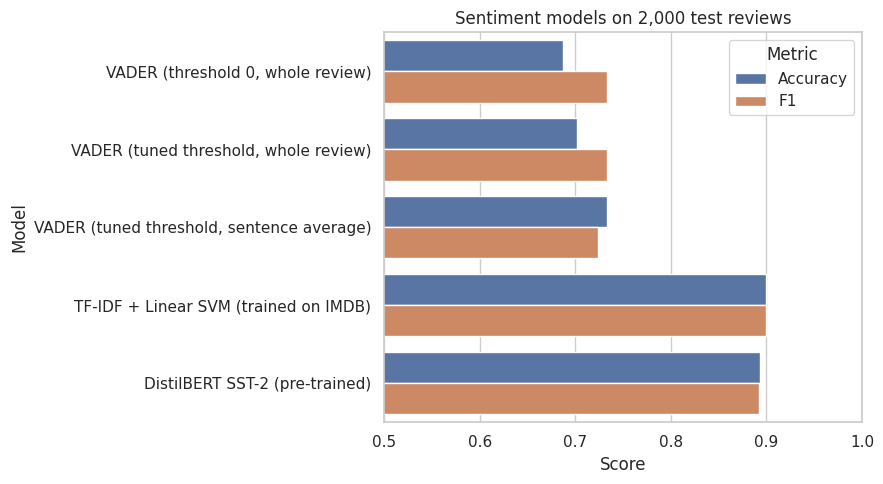

In [11]:
y_s = test_sample["label"]
sample_preds = {
    "VADER (threshold 0, whole review)": (test_sample["v_whole"] >= 0).astype(int),
    "VADER (tuned threshold, whole review)": (test_sample["v_whole"] >= best_t_whole).astype(int),
    "VADER (tuned threshold, sentence average)": (test_sample["v_sent"] >= best_t_sent).astype(int),
    "TF-IDF + Linear SVM (trained on IMDB)": test_df.loc[test_sample.index, "svm_pred"],
    "DistilBERT SST-2 (pre-trained)": trans_pred,
}
sent_results = pd.DataFrame([{"Model": n, **metrics(y_s, p)} for n, p in sample_preds.items()])
display(sent_results.round(4))
sent_results.to_csv("outputs/table_sentiment_results_sample2000.csv", index=False)

# Same VADER and SVM variants on the FULL test set
y_t = test_df["label"]
full_preds = {
    "VADER (threshold 0, whole review)": (test_df["v_whole"] >= 0).astype(int),
    "VADER (tuned threshold, whole review)": (test_df["v_whole"] >= best_t_whole).astype(int),
    "VADER (tuned threshold, sentence average)": (test_df["v_sent"] >= best_t_sent).astype(int),
    "TF-IDF + Linear SVM (trained on IMDB)": test_df["svm_pred"],
}
sent_full = pd.DataFrame([{"Model": n, **metrics(y_t, p)} for n, p in full_preds.items()])
print(f"\nFull test set ({len(test_df)} reviews):")
display(sent_full.round(4))
sent_full.to_csv("outputs/table_sentiment_results_full_test.csv", index=False)

plot_df = sent_results.melt(id_vars="Model", value_vars=["Accuracy", "F1"], var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, y="Model", x="Score", hue="Metric", palette=["#4c72b0", "#dd8452"])
plt.xlim(0.5, 1.0); plt.title("Sentiment models on 2,000 test reviews")
save("03_sentiment_model_comparison")

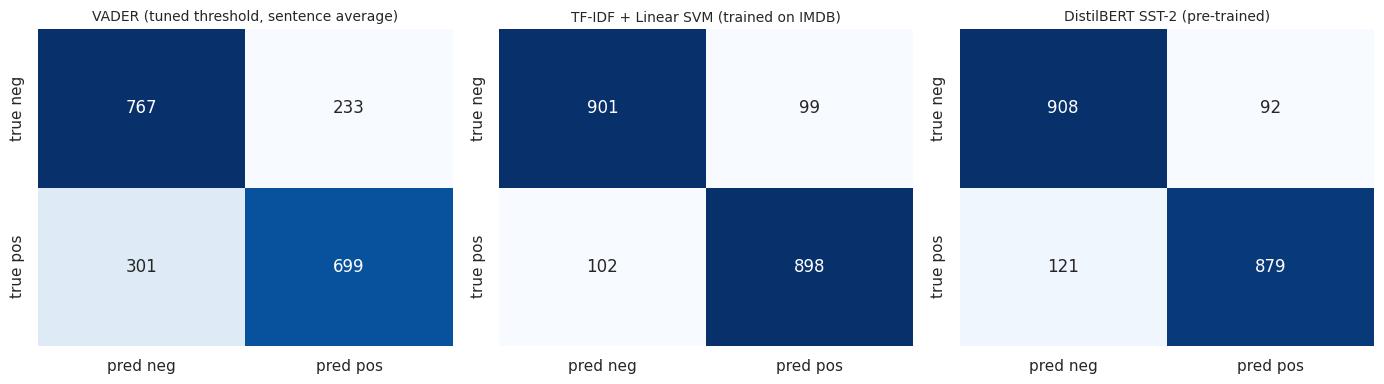

In [12]:
# Confusion matrices for the best VADER variant, the SVM and DistilBERT
best_vader = sent_results.iloc[:3].sort_values("Accuracy", ascending=False).iloc[0]["Model"]
chosen = [best_vader, "TF-IDF + Linear SVM (trained on IMDB)", "DistilBERT SST-2 (pre-trained)"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, n in zip(axes, chosen):
    sns.heatmap(confusion_matrix(y_s, sample_preds[n]), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred neg", "pred pos"], yticklabels=["true neg", "true pos"])
    ax.set_title(n, fontsize=10)
save("04_sentiment_confusion_matrices")

In [13]:
# Error analysis: where do the SVM and DistilBERT disagree?
ok_svm = sample_preds["TF-IDF + Linear SVM (trained on IMDB)"] == y_s
ok_trf = sample_preds["DistilBERT SST-2 (pre-trained)"] == y_s
print("Both correct :", int((ok_svm & ok_trf).sum()))
print("Only DistilBERT correct:", int((~ok_svm & ok_trf).sum()))
print("Only SVM correct       :", int((ok_svm & ~ok_trf).sum()))
print("Both wrong   :", int((~ok_svm & ~ok_trf).sum()))

for title, mask in [("DistilBERT right, SVM wrong", ~ok_svm & ok_trf), ("SVM right, DistilBERT wrong", ok_svm & ~ok_trf)]:
    print(f"\n===== {title} =====")
    for idx in test_sample[mask].sample(min(2, int(mask.sum())), random_state=SEED).index:
        print(f"[true: {'positive' if test_df.loc[idx, 'label'] == 1 else 'negative'}] {strip_html(test_df.loc[idx, 'text'])[:350]}...\n")

Both correct : 1656
Only DistilBERT correct: 131
Only SVM correct       : 143
Both wrong   : 70

===== DistilBERT right, SVM wrong =====
[true: negative] I wish I knew what to make of a movie like this. It seems to be divided into two parts -- action sequences and personal dramas ashore. It follows Ashton Kutsher through survival swimmer school, guided by Master Chief Kevin Costner, then to Alaska where a couple of spectacular rescues take place, the last resulting in death.  I must say that the sce...

[true: negative] I bought this film from e-bay as part of a lot of about twenty horror flicks, all about a dollar a piece. When watching this, my first impression was that it probably was from the late 80s. Later on I began thinking - the Linkin Park posters on the wall and everything else seemed to hint that I was dealing with a more recent film. Realizing that, t...


===== SVM right, DistilBERT wrong =====
[true: positive] I'm from Phoenix city and the first time i saw this movie and

> **Note for your report (Sentiment evaluation):** the 2,000-review comparison table and the full-test table, the best VADER threshold and what changed (default vs tuned, whole vs sentence average), and which model wins. Explain the trade-offs: the lexicon needs no training but is weakest; the SVM is trained on in-domain data; DistilBERT is strong without any IMDB training but slowest and truncates long reviews. Use the disagreement examples for your discussion.

## Phase 4: Project B, Named entity recognition
Entities follow the CoNLL types **PER** (person), **ORG** (organisation), **LOC** (location) and **MISC** (everything else, such as nationalities and titles of works). Tags use the **BIO scheme**: `B-` begins an entity, `I-` continues it, `O` is outside.

Three systems from three paradigms:
1. **Rule-based:** capitalisation patterns plus small gazetteers and keyword rules.
2. **Statistical:** spaCy `en_core_web_sm` (a CNN-based model trained on OntoNotes).
3. **Deep learning:** `dslim/bert-base-NER` (BERT fine-tuned on CoNLL-2003).

**Metric:** *entity-level* precision, recall and F1, computed with the standard CoNLL scoring rules (implemented in Phase 0). An entity counts as correct only if both its boundaries and its type match exactly.

### 4.1 Utilities and the three systems

In [14]:
# ---- helper: BIO tags -> list of (surface text, type) ----
def bio_to_spans(tokens, tags):
    spans, start, typ = [], None, None
    for i, tag in enumerate(list(tags) + ["O"]):
        if tag == "O" or tag.startswith("B-") or (tag.startswith("I-") and tag[2:] != typ):
            if start is not None:
                spans.append((" ".join(tokens[start:i]), typ))
                start, typ = None, None
            if tag != "O":
                start, typ = i, tag[2:]
    return spans

# ---- System 1: rule-based tagger ----
COMMON = set("""the a an in on at of to for and but or if as by with from this that these those it he she they we you i his her
their our my your its there here when where what who how why then than so not no yes after before during while about into
over under again also just more most some such only own same too very can will would could should may might must shall do
does did has have had is are was were be been being""".split())
CONNECT = {"of", "de", "van", "von", "der", "la", "le", "del", "al", "&"}
TITLES = {"mr", "mrs", "ms", "dr", "prof", "president", "minister", "sir", "lord", "king", "queen", "coach", "captain",
          "general", "senator", "premier", "judge"}
ORG_WORDS = {"inc", "corp", "ltd", "company", "bank", "university", "club", "fc", "united", "association", "ministry",
             "party", "council", "committee", "league", "group", "agency", "institute", "airlines", "army", "police",
             "court", "federation", "union", "studios", "pictures", "films", "bros", "ltd.", "co", "plc"}
LOC_GAZ = set("""germany france italy spain england britain russia china japan india australia canada brazil argentina mexico
israel iraq iran u.s. usa us uk london paris berlin moscow tokyo beijing washington chicago rome madrid sydney
new york los angeles san francisco boston atlanta seoul delhi cairo istanbul athens vienna brussels amsterdam
california texas florida georgia ohio scotland wales ireland sweden norway denmark finland poland ukraine turkey egypt
pakistan afghanistan syria lebanon jordan kuwait bosnia serbia croatia hungary romania bulgaria greece portugal
switzerland austria belgium netherlands europe asia africa america hollywood""".split() + ["new york", "los angeles", "san francisco"])

def is_cap(tok):
    return tok[:1].isupper()

def classify_span(span, prev, first):
    joined = " ".join(span).lower()
    if joined in LOC_GAZ:
        return "LOC"
    if any(w.lower() in ORG_WORDS for w in span):
        return "ORG"
    if prev.lower().strip(".") in TITLES:
        return "PER"
    if len(span) == 1:
        if first:
            return None                      # sentence-initial single word: too ambiguous
        w = span[0]
        return "ORG" if (w.isupper() and len(w) >= 2) else "MISC"
    return "PER" if len(span) <= 3 else "MISC"

def rule_tags(tokens):
    n, tags, i = len(tokens), ["O"] * len(tokens), 0
    while i < n:
        tok = tokens[i]
        if is_cap(tok) and tok.lower() not in COMMON:
            j = i + 1
            while j < n:
                if is_cap(tokens[j]) and tokens[j].lower() not in COMMON:
                    j += 1
                elif tokens[j].lower() in CONNECT and j + 1 < n and is_cap(tokens[j + 1]):
                    j += 2
                else:
                    break
            typ = classify_span(tokens[i:j], tokens[i - 1] if i > 0 else "", i == 0)
            if typ:
                tags[i] = "B-" + typ
                for k in range(i + 1, j):
                    tags[k] = "I-" + typ
            i = j
        else:
            i += 1
    return tags

def rule_tags_batch(token_lists):
    return [rule_tags(t) for t in token_lists]

print(list(zip(test_tokens[2], rule_tags(test_tokens[2]))))

[('AL-AIN', 'O'), (',', 'O'), ('United', 'B-ORG'), ('Arab', 'I-ORG'), ('Emirates', 'I-ORG'), ('1996-12-06', 'O')]


In [15]:
# ---- System 2: spaCy (statistical) ----
try:
    nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "attribute_ruler", "lemmatizer"])
except OSError:
    raise SystemExit("spaCy model not found: use Runtime -> Restart session, then run again from the imports cell.")
SPACY_MAP = {"PERSON": "PER", "ORG": "ORG", "GPE": "LOC", "LOC": "LOC", "FAC": "LOC", "NORP": "MISC", "EVENT": "MISC",
             "WORK_OF_ART": "MISC", "PRODUCT": "MISC", "LAW": "MISC", "LANGUAGE": "MISC"}
# DATE, TIME, MONEY, PERCENT, QUANTITY, CARDINAL, ORDINAL have no CoNLL equivalent and are treated as "O"

def spacy_tags_batch(token_lists, lower=False):
    docs = [Doc(nlp.vocab, words=[w.lower() for w in toks] if lower else list(toks)) for toks in token_lists]
    result = []
    for doc in nlp.pipe(docs, batch_size=64):
        tags = []
        for tok in doc:
            lab = SPACY_MAP.get(tok.ent_type_) if tok.ent_iob_ in ("B", "I") else None
            tags.append("O" if lab is None else ("B-" if tok.ent_iob_ == "B" else "I-") + lab)
        result.append(tags)
    return result

# ---- System 3: BERT fine-tuned on CoNLL-2003 ----
bert_tok = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
bert_model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER").to(DEVICE).eval()
BERT_ID2LABEL = bert_model.config.id2label

def bert_tags_batch(token_lists, batch_size=32):
    result = []
    for i in range(0, len(token_lists), batch_size):
        batch = [list(t) for t in token_lists[i:i + batch_size]]
        enc = bert_tok(batch, is_split_into_words=True, truncation=True, max_length=256, padding=True, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            pred_ids = bert_model(**inputs).logits.argmax(-1).cpu().numpy()
        for b, toks in enumerate(batch):
            tags, seen = ["O"] * len(toks), set()
            for pos, w in enumerate(enc.word_ids(batch_index=b)):
                if w is None or w in seen:
                    continue
                seen.add(w)
                tags[w] = BERT_ID2LABEL[int(pred_ids[b, pos])]
            result.append(tags)
    return result

print("Systems ready. Example sentence:", " ".join(test_tokens[0]))
for name, fn in [("Rule-based", rule_tags_batch), ("spaCy", spacy_tags_batch), ("BERT", bert_tags_batch)]:
    print(f"{name:11s}", bio_to_spans(test_tokens[0], fn([test_tokens[0]])[0]))
print("Gold       ", bio_to_spans(test_tokens[0], test_tags[0]))

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Systems ready. Example sentence: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Rule-based  [('JAPAN GET LUCKY WIN', 'MISC'), ('CHINA', 'LOC'), ('SURPRISE DEFEAT', 'PER')]
spaCy       [('DEFEAT', 'ORG')]
BERT        [('JAPAN', 'MISC'), ('LUCKY', 'PER'), ('CHINA', 'ORG')]
Gold        [('JAPAN', 'LOC'), ('CHINA', 'PER')]


### 4.2 Evaluation on CoNLL-2003 (gold annotations)

Rule-based: tagged 3453 sentences in 0s
spaCy (statistical): tagged 3453 sentences in 8s
BERT (deep learning): tagged 3453 sentences in 9s


,System,Precision,Recall,F1
0,Rule-based,0.4300,0.4219,0.4259
1,spaCy (statistical),0.6554,0.5446,0.5949
2,BERT (deep learning),0.9066,0.9193,0.9129


System,BERT (deep learning),Rule-based,spaCy (statistical)
Type,,,
LOC,0.9307,0.6547,0.7488
MISC,0.8042,0.2167,0.6140
ORG,0.8993,0.2460,0.3594
PER,0.9573,0.5393,0.6456


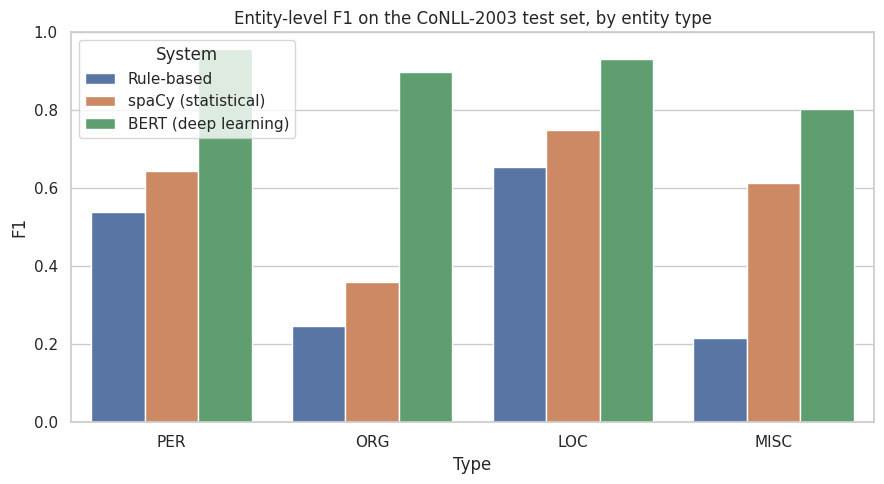

In [16]:
t0 = time.time()
ner_pred = {}
for name, fn in [("Rule-based", rule_tags_batch), ("spaCy (statistical)", spacy_tags_batch), ("BERT (deep learning)", bert_tags_batch)]:
    t1 = time.time()
    ner_pred[name] = fn(test_tokens)
    print(f"{name}: tagged {len(test_tokens)} sentences in {time.time() - t1:.0f}s")

rows = []
for name, pred in ner_pred.items():
    rows.append({"System": name, "Precision": seq_p(test_tags, pred), "Recall": seq_r(test_tags, pred), "F1": seq_f1(test_tags, pred)})
ner_results = pd.DataFrame(rows)
display(ner_results.round(4))
ner_results.to_csv("outputs/table_ner_results_conll.csv", index=False)

# per-type F1
type_rows = []
for name, pred in ner_pred.items():
    rep = seq_report(test_tags, pred, output_dict=True)
    for typ in ["PER", "ORG", "LOC", "MISC"]:
        r = rep.get(typ, {"precision": 0.0, "recall": 0.0, "f1-score": 0.0, "support": 0})
        type_rows.append({"System": name, "Type": typ, "Precision": r["precision"], "Recall": r["recall"],
                          "F1": r["f1-score"], "Support": int(r["support"])})
ner_by_type = pd.DataFrame(type_rows)
display(ner_by_type.pivot(index="Type", columns="System", values="F1").round(4))
ner_by_type.to_csv("outputs/table_ner_by_type.csv", index=False)

sns.barplot(data=ner_by_type, x="Type", y="F1", hue="System")
plt.ylim(0, 1); plt.title("Entity-level F1 on the CoNLL-2003 test set, by entity type")
save("05_ner_f1_by_type")

In [17]:
# Why NER must keep capitalisation: run spaCy on lower-cased tokens
lower_pred = spacy_tags_batch(test_tokens, lower=True)
lower_f1 = seq_f1(test_tags, lower_pred)
orig_f1 = seq_f1(test_tags, ner_pred["spaCy (statistical)"])
lower_ablation = pd.DataFrame({"Input to spaCy": ["Original case", "Lower-cased"], "Entity F1": [orig_f1, lower_f1]})
display(lower_ablation.round(4))
lower_ablation.to_csv("outputs/table_ner_lowercase_ablation.csv", index=False)
print(f"F1 drops by {orig_f1 - lower_f1:.3f} ({(orig_f1 - lower_f1) / orig_f1:.1%} relative) when the text is lower-cased")

,Input to spaCy,Entity F1
0,Original case,0.5949
1,Lower-cased,0.4446


F1 drops by 0.150 (25.3% relative) when the text is lower-cased


In [18]:
# Error analysis: which entity types are confused? (token-level confusion between types for the spaCy model)
def type_of(tag):
    return "O" if tag == "O" else tag[2:]

for name in ["spaCy (statistical)", "BERT (deep learning)"]:
    gold = [type_of(t) for tags in test_tags for t in tags]
    pred = [type_of(t) for tags in ner_pred[name] for t in tags]
    labels = ["PER", "ORG", "LOC", "MISC", "O"]
    cm = pd.DataFrame(confusion_matrix(gold, pred, labels=labels), index=[f"gold {l}" for l in labels], columns=[f"pred {l}" for l in labels])
    print(f"\n{name}: token-level confusion (rows = gold, columns = predicted)")
    display(cm)


spaCy (statistical): token-level confusion (rows = gold, columns = predicted)


,pred PER,pred ORG,pred LOC,pred MISC,pred O
gold PER,1914,311,63,39,446
gold ORG,299,1209,290,57,641
gold LOC,66,198,1419,32,210
gold MISC,27,122,23,520,226
gold O,158,548,87,144,37386



BERT (deep learning): token-level confusion (rows = gold, columns = predicted)


,pred PER,pred ORG,pred LOC,pred MISC,pred O
gold PER,2705,28,21,3,16
gold ORG,24,2317,60,52,43
gold LOC,12,76,1790,27,20
gold MISC,8,53,28,775,54
gold O,31,82,25,116,38069


> **Note for your report (NER evaluation):** the results table (precision, recall, F1 for the three systems), the per-type table and chart, the lower-casing ablation, and the confusion matrices. Explain *why* each system behaves as it does: the rule-based tagger relies on capitalisation and gazetteers (low precision), spaCy was trained on a different corpus (OntoNotes, with a different label set that had to be mapped), and BERT was fine-tuned on CoNLL-2003 itself, so its score is an in-domain best case.

### 4.3 Domain probe: NER on movie-review style text
CoNLL is news. To see how the systems cope with **review-style sentences**, a small probe set of 30 sentences was written for this report, with hand-annotated gold entities (actors and directors = PER, studios = ORG, places = LOC, film titles and nationalities = MISC). Two sentences contain no entities. This set is **small and annotated by the author**, so treat the numbers as indicative only.

In [19]:
PROBE = [
 ("Christopher Nolan directed Inception for Warner Bros in 2010.", [("Christopher Nolan","PER"),("Inception","MISC"),("Warner Bros","ORG")]),
 ("Tom Hanks gives a wonderful performance in Forrest Gump, which was shot mostly in Georgia.", [("Tom Hanks","PER"),("Forrest Gump","MISC"),("Georgia","LOC")]),
 ("I watched Parasite at a cinema in Seoul and loved every minute of it.", [("Parasite","MISC"),("Seoul","LOC")]),
 ("The Italian director Federico Fellini made La Dolce Vita in Rome.", [("Italian","MISC"),("Federico Fellini","PER"),("La Dolce Vita","MISC"),("Rome","LOC")]),
 ("Disney remade Aladdin with Will Smith, and the result is mediocre.", [("Disney","ORG"),("Aladdin","MISC"),("Will Smith","PER")]),
 ("Russell Crowe is magnificent in Gladiator, directed by Ridley Scott.", [("Russell Crowe","PER"),("Gladiator","MISC"),("Ridley Scott","PER")]),
 ("Netflix released Roma, a black-and-white drama set in Mexico City.", [("Netflix","ORG"),("Roma","MISC"),("Mexico City","LOC")]),
 ("Quentin Tarantino fans will enjoy Pulp Fiction, though the dialogue drags in the middle.", [("Quentin Tarantino","PER"),("Pulp Fiction","MISC")]),
 ("Shah Rukh Khan stars in Dilwale, a film shot partly in Iceland and Bulgaria.", [("Shah Rukh Khan","PER"),("Dilwale","MISC"),("Iceland","LOC"),("Bulgaria","LOC")]),
 ("Universal Pictures should have spent more money on the script of Waterworld.", [("Universal Pictures","ORG"),("Waterworld","MISC")]),
 ("Sean Connery was the best James Bond in my opinion.", [("Sean Connery","PER"),("James Bond","PER")]),
 ("Filmed in New Zealand, Lord of the Rings looks spectacular.", [("New Zealand","LOC"),("Lord of the Rings","MISC")]),
 ("Steven Spielberg made Jaws, and John Williams wrote an unforgettable score.", [("Steven Spielberg","PER"),("Jaws","MISC"),("John Williams","PER")]),
 ("Denzel Washington saved Flight from being a forgettable drama.", [("Denzel Washington","PER"),("Flight","MISC")]),
 ("Amazon Studios and BBC Films co-produced this slow burner set in London.", [("Amazon Studios","ORG"),("BBC Films","ORG"),("London","LOC")]),
 ("Brad Pitt is miscast as a German soldier in Inglourious Basterds.", [("Brad Pitt","PER"),("German","MISC"),("Inglourious Basterds","MISC")]),
 ("I rented Casablanca on the recommendation of a friend from Chicago.", [("Casablanca","MISC"),("Chicago","LOC")]),
 ("Hayao Miyazaki directed Spirited Away, the masterpiece that made Studio Ghibli famous.", [("Hayao Miyazaki","PER"),("Spirited Away","MISC"),("Studio Ghibli","ORG")]),
 ("Honestly, this was a waste of two hours, and the director should be ashamed.", []),
 ("Martin Scorsese cast Leonardo DiCaprio in Shutter Island, filmed near Boston.", [("Martin Scorsese","PER"),("Leonardo DiCaprio","PER"),("Shutter Island","MISC"),("Boston","LOC")]),
 ("Sony and Marvel Studios made this film together, shot in Atlanta.", [("Sony","ORG"),("Marvel Studios","ORG"),("Atlanta","LOC")]),
 ("Judi Dench steals the show in Skyfall.", [("Judi Dench","PER"),("Skyfall","MISC")]),
 ("The soundtrack, composed by Hans Zimmer, is the only good thing about Armageddon.", [("Hans Zimmer","PER"),("Armageddon","MISC")]),
 ("Warner Bros keeps making sequels nobody asked for, like Gremlins 2.", [("Warner Bros","ORG"),("Gremlins 2","MISC")]),
 ("I saw this at the Cannes festival and the French audience applauded for five minutes.", [("Cannes","LOC"),("French","MISC")]),
 ("Bruce Willis plays a cop in Los Angeles in Die Hard.", [("Bruce Willis","PER"),("Los Angeles","LOC"),("Die Hard","MISC")]),
 ("Pixar did it again with Ratatouille, a love letter to Paris.", [("Pixar","ORG"),("Ratatouille","MISC"),("Paris","LOC")]),
 ("Idris Elba is the only reason to watch Pacific Rim.", [("Idris Elba","PER"),("Pacific Rim","MISC")]),
 ("The pacing is terrible and the ending makes no sense at all.", []),
 ("Akira Kurosawa influenced Hollywood with Seven Samurai.", [("Akira Kurosawa","PER"),("Hollywood","LOC"),("Seven Samurai","MISC")]),
]

TOKEN_RE = re.compile(r"\w+(?:[-'\u2019]\w+)*|[^\w\s]")
probe_tokens = [TOKEN_RE.findall(s) for s, _ in PROBE]
gold_strict = {(i, s, t) for i, (_, ents) in enumerate(PROBE) for (s, t) in ents}
gold_span = {(i, s) for (i, s, t) in gold_strict}

def prf(gold, pred):
    tp = len(gold & pred)
    p, r = (tp / len(pred) if pred else 0.0), (tp / len(gold) if gold else 0.0)
    return p, r, (2 * p * r / (p + r) if p + r else 0.0)

probe_pred_tags, probe_rows = {}, []
for name, fn in [("Rule-based", rule_tags_batch), ("spaCy (statistical)", spacy_tags_batch), ("BERT (deep learning)", bert_tags_batch)]:
    tags = fn(probe_tokens)
    probe_pred_tags[name] = tags
    pred_strict = {(i, s, t) for i, (tk, tg) in enumerate(zip(probe_tokens, tags)) for (s, t) in bio_to_spans(tk, tg)}
    pred_span = {(i, s) for (i, s, t) in pred_strict}
    ps, rs, fs = prf(gold_strict, pred_strict)
    pl, rl, fl = prf(gold_span, pred_span)
    probe_rows.append({"System": name, "Precision (strict)": ps, "Recall (strict)": rs, "F1 (strict)": fs,
                       "F1 (boundaries only)": fl})
probe_results = pd.DataFrame(probe_rows)
print(f"Probe set: {len(PROBE)} sentences, {len(gold_strict)} gold entities")
display(probe_results.round(3))
probe_results.to_csv("outputs/table_ner_probe_results.csv", index=False)

Probe set: 30 sentences, 75 gold entities


,System,Precision (strict),Recall (strict),F1 (strict),F1 (boundaries only)
0,Rule-based,0.750,0.720,0.735,0.925
1,spaCy (statistical),0.691,0.627,0.657,0.923
2,BERT (deep learning),0.908,0.920,0.914,0.980


In [20]:
# Which film titles and entities go wrong? (show misses for spaCy and BERT)
for name in ["spaCy (statistical)", "BERT (deep learning)"]:
    pred = {(i, s, t) for i, (tk, tg) in enumerate(zip(probe_tokens, probe_pred_tags[name])) for (s, t) in bio_to_spans(tk, tg)}
    wrong_type = sorted((s, t_gold, [t for (j, s2, t) in pred if j == i and s2 == s]) for (i, s, t_gold) in gold_strict
                        if (i, s, t_gold) not in pred and any(j == i and s2 == s for (j, s2, _) in pred))
    missed = sorted((s, t) for (i, s, t) in gold_strict if (i, s, t) not in pred and not any(j == i and s2 == s for (j, s2, _) in pred))
    print(f"\n===== {name} =====")
    print(f"Right boundaries but wrong type ({len(wrong_type)}):", [(s, f"gold {g}", f"pred {p}") for s, g, p in wrong_type][:12])
    print(f"Not found at all ({len(missed)}):", missed[:12])


===== spaCy (statistical) =====
Right boundaries but wrong type (19): [('Aladdin', 'gold MISC', "pred ['PER']"), ('Armageddon', 'gold MISC', "pred ['LOC']"), ('Cannes', 'gold LOC', "pred ['MISC']"), ('Denzel Washington', 'gold PER', "pred ['ORG']"), ('Dilwale', 'gold MISC', "pred ['LOC']"), ('Forrest Gump', 'gold MISC', "pred ['PER']"), ('Gladiator', 'gold MISC', "pred ['ORG']"), ('Inglourious Basterds', 'gold MISC', "pred ['PER']"), ('Jaws', 'gold MISC', "pred ['PER']"), ('La Dolce Vita', 'gold MISC', "pred ['LOC']"), ('Pacific Rim', 'gold MISC', "pred ['LOC']"), ('Pulp Fiction', 'gold MISC', "pred ['ORG']")]
Not found at all (9): [('Casablanca', 'MISC'), ('Die Hard', 'MISC'), ('Flight', 'MISC'), ('Gremlins 2', 'MISC'), ('Inception', 'MISC'), ('Lord of the Rings', 'MISC'), ('Parasite', 'MISC'), ('Seven Samurai', 'MISC'), ('Shah Rukh Khan', 'PER')]

===== BERT (deep learning) =====
Right boundaries but wrong type (5): [('Flight', 'gold MISC', "pred ['ORG']"), ('Pacific Rim', 'gold MIS

> **Note for your report (Domain shift):** the probe table (strict F1 vs boundaries-only F1), and the examples of **right boundary, wrong type**. A typical finding is that film titles are recognised as entities but typed as PER, ORG or MISC inconsistently, because news-trained models have rarely seen titles of works. State clearly that the probe set is small and written by the author.

### 4.4 NER applied to IMDB reviews
spaCy is applied to a random sample of 5,000 **test** reviews (HTML removed, original case kept). The OntoNotes label set is used here, since there is no gold to map against.

spaCy tagged 5000 reviews in 93s | entities found: 60,358


,Entity label,Count
0,PERSON,22888
1,ORG,8857
2,CARDINAL,7036
3,GPE,4707
4,DATE,4641
5,NORP,3461
6,WORK_OF_ART,2715
7,ORDINAL,2068
8,TIME,1424
9,LOC,629


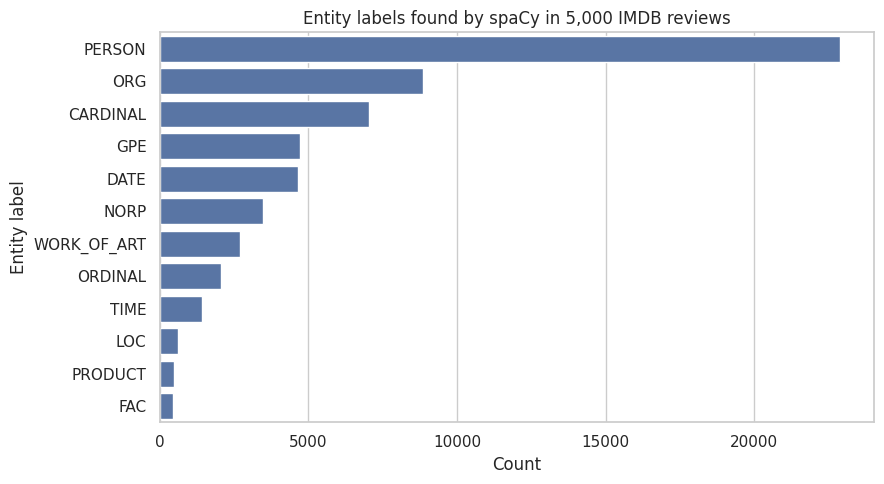

,PERSON,ORG,GPE,WORK_OF_ART
0,gore (145),Hitchcock (105),Hollywood (357),Batman (29)
1,Oscar (92),Disney (79),America (116),Bible (18)
2,Shakespeare (62),VHS (50),US (89),Star Trek (14)
3,Jack (57),BBC (49),New York (73),Love (13)
4,Jason (55),Ford (39),London (61),Hercules (12)
5,Prot (54),FBI (39),France (59),Yusuf (11)
6,Michael (53),CGI (38),Paris (47),Hamlet (10)
7,Guy (50),Fulci (36),Texas (43),The Thing (7)
8,Chaplin (45),Batman (36),UK (42),Tipping the Velvet (7)
9,Bruno (45),HBO (34),India (40),Saboteur (7)


In [21]:
ner_sample = test_df.sample(5000, random_state=SEED)
texts = [strip_html(t) for t in ner_sample["text"]]
t0 = time.time()
ent_lists = [[(e.text.strip(), e.label_) for e in doc.ents] for doc in nlp.pipe(texts, batch_size=64)]
print(f"spaCy tagged {len(texts)} reviews in {time.time() - t0:.0f}s | entities found: {sum(len(e) for e in ent_lists):,}")

label_counts = collections.Counter(l for ents in ent_lists for _, l in ents)
lc = pd.DataFrame(label_counts.most_common(12), columns=["Entity label", "Count"])
display(lc)
lc.to_csv("outputs/table_imdb_entity_labels.csv", index=False)
sns.barplot(data=lc, y="Entity label", x="Count", color="#4c72b0")
plt.title("Entity labels found by spaCy in 5,000 IMDB reviews")
save("06_imdb_entity_types")

def top_entities(label, k=12):
    c = collections.Counter(t for ents in ent_lists for t, l in ents if l == label)
    return [f"{t} ({n})" for t, n in c.most_common(k)]

top_table = pd.DataFrame({lab: pd.Series(top_entities(lab)) for lab in ["PERSON", "ORG", "GPE", "WORK_OF_ART"]}).fillna("")
display(top_table)
top_table.to_csv("outputs/table_imdb_top_entities.csv", index=False)

In [22]:
# A few reviews with their entities (for qualitative discussion)
for (idx, row), ents in list(zip(ner_sample.iterrows(), ent_lists))[:4]:
    print(strip_html(row["text"])[:260], "...")
    print("   ->", [(t, l) for t, l in ents][:10], "\n")

Another masterpiece that needs a DVD release but some libraries have the VHS and well worth seeking out. Just a brilliant play about many things, foremost being euthanasia, "respectability", religion, and fundamental human relationships. The script effectively ...
   -> [('VHS', 'ORG'), ('Alan Bates', 'PERSON'), ('Janet Suzman', 'PERSON'), ('Bates', 'PERSON'), ('a couple years', 'DATE'), ('Joe Egg', 'PERSON'), ('Butley', 'GPE'), ('The Go-Between', 'WORK_OF_ART'), ('Women in Love', 'WORK_OF_ART'), ('Whistle Down the Wind', 'WORK_OF_ART')] 

Coming from Kiarostami, this art-house visual and sound exposition is a surprise. For a director known for his narratives and keen observation of humans, especially children, this excursion into minimalist cinematography begs for questions: Why did he do it? W ...
   -> [('Kiarostami', 'GPE'), ('Five', 'CARDINAL'), ('5', 'CARDINAL'), ('five', 'CARDINAL'), ('Ten minutes', 'TIME'), ('Eleven minutes', 'TIME'), ('Six', 'CARDINAL'), ('six', 'CARDINAL'), (

> **Note for your report (NER on reviews):** the entity-label chart, the top-entities table and 2 to 3 observations: which entity types dominate, whether the top PERSON names are actors and directors, and any entities that look wrong (film titles tagged as PERSON or ORG, for example).

## Phase 5: Integration, entity-level sentiment
The two projects are combined: for every full person name found by NER in a review, the review's sentiment score (from the SVM) is recorded. Averaging over all reviews that mention a person shows which actors and directors are associated with positive or negative reviews.

**Caution:** this is the sentiment of the *whole review*, not of the sentence about the person, so it is an association, not proof that the person caused it.

People mentioned in at least 8 reviews: 64
Correlation between mean SVM score and % of truly positive reviews: 0.912


,name,reviews,mean_svm_score,pct_positive
0,Dustin Hoffman,8,0.948,1.000
1,Martin Sheen,8,0.880,1.000
2,Michelle Pfeiffer,12,0.771,1.000
3,Kevin James,8,0.771,1.000
4,Myrna Loy,9,0.735,0.889
5,Marlon Brando,8,0.716,0.875
6,Christopher Eccleston,8,0.662,0.875
7,Danny DeVito,8,0.638,1.000
8,Will Smith,9,0.628,0.889
9,Brian Keith,8,0.609,0.875


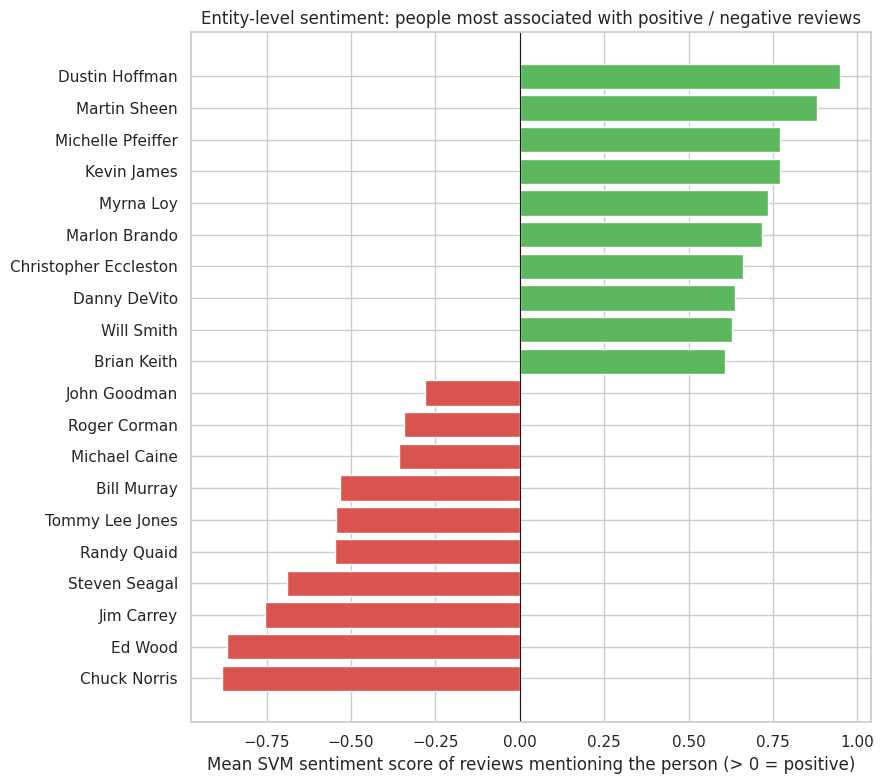

In [23]:
MIN_MENTIONS = 8
rows = []
for ents, (idx, row) in zip(ent_lists, ner_sample.iterrows()):
    for name in {t for t, l in ents if l == "PERSON" and len(t.split()) >= 2}:
        rows.append({"name": name, "svm_score": row["svm_score"], "label": row["label"]})

ent_df = pd.DataFrame(rows).groupby("name").agg(reviews=("label", "size"), mean_svm_score=("svm_score", "mean"),
                                                pct_positive=("label", "mean")).reset_index()
ent_df = ent_df[ent_df["reviews"] >= MIN_MENTIONS].sort_values("mean_svm_score", ascending=False).reset_index(drop=True)
print(f"People mentioned in at least {MIN_MENTIONS} reviews: {len(ent_df)}")
print("Correlation between mean SVM score and % of truly positive reviews:",
      round(ent_df[["mean_svm_score", "pct_positive"]].corr().iloc[0, 1], 3))

show = pd.concat([ent_df.head(10), ent_df.tail(10)]).drop_duplicates("name")
display(show.round(3))
show.to_csv("outputs/table_entity_level_sentiment.csv", index=False)

plt.figure(figsize=(9, 8))
plt.barh(show["name"][::-1], show["mean_svm_score"][::-1], color=["#5cb85c" if v > 0 else "#d9534f" for v in show["mean_svm_score"][::-1]])
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("Mean SVM sentiment score of reviews mentioning the person (> 0 = positive)")
plt.title("Entity-level sentiment: people most associated with positive / negative reviews")
save("07_entity_level_sentiment")

> **Note for your report (Integration):** the number of people with enough mentions, the correlation value, the most positive and most negative names (are they actors, directors? well-known cult films?) and the limitations: name variants ("Hitchcock" vs "Alfred Hitchcock") are counted separately, only full names (two or more words) are used, and review-level sentiment is not the same as sentiment towards the person.

## Export and versions

In [24]:
import importlib.metadata as md
print("Python:", sys.version.split()[0])
for lib in ["scikit-learn", "pandas", "numpy", "nltk", "spacy", "transformers", "torch", "datasets",
            "vaderSentiment", "matplotlib", "seaborn"]:
    print(lib, md.version(lib))                    # put these in your report appendix
print("spaCy model en_core_web_sm", nlp.meta["version"])

Python: 3.13.15
scikit-learn 1.6.1
pandas 2.2.3
numpy 2.1.3
nltk 3.9.1
spacy 3.8.16
transformers 5.18.0
torch 2.11.0+cu130
datasets 4.8.5
vaderSentiment 3.3.2
matplotlib 3.10.0
seaborn 0.13.2
spaCy model en_core_web_sm 3.8.0


In [25]:
import shutil
shutil.make_archive("week3_outputs", "zip", "outputs")
try:
    from google.colab import files
    files.download("week3_outputs.zip")
except ImportError:
    print("Not running in Colab: find week3_outputs.zip in the working folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Mapping this notebook to your report
| Report section | Notebook source |
|---|---|
| Datasets and justification | Phase 1 |
| Preprocessing | Phase 2 and the lowercase ablation in Phase 4.2 |
| Sentiment analysis project | Phase 3 |
| NER project | Phase 4 |
| Integration | Phase 5 |
| Appendix (reproducibility) | Version cells and the notebook link |

**Before submitting:** use `Runtime → Restart session and run all` to confirm everything runs from the top.